# Polynomial Regression — OLS Comparison and Train-Test Evaluation

This notebook uses the functions from `poly_ols.py` without modifying that file.

Flow:
1. Import and auto-reload the Python module.
2. Generate the dataset.
3. Set the polynomial `degree` in one place.
4. Create polynomial features.
5. Compare:
   - OLS using `fit_multiple_lr`
   - Manual OLS using `fit_multiple_lr_beta`
   - Scikit-learn OLS
6. Visualize the comparison.
7. Perform a train-test split.
8. Train using the manual OLS function.
9. Predict test data and evaluate residuals / R².
10. Final visualization.


### Load Libraries and Existing OLS Functions

This cell imports NumPy, Matplotlib, the Scikit-learn utilities, and the functions from `poly_ols.py`.

**Important:** the existing Python implementation is used as-is; this notebook only calls its functions.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from poly_ols import *


## 1. Dataset and Polynomial Degree

### Generate the Nonlinear Dataset

The notebook uses a degree-5 polynomial and generates 70 input values over $[0,\pi]$.

The target is

$y = \sin(X) + \sin(3X) + \epsilon$

where

$\epsilon = U - 0.5,\qquad U \sim \mathrm{Uniform}(0,1)$.

The random seed makes the generated noise reproducible.

In [2]:
degree = 5

np.random.seed(50)

X = np.linspace(0, np.pi, 70)

y = (
    np.sin(X)
    + np.sin(3 * X)
    + (np.random.random(len(X)) - 0.5)
)


## 2. Create Polynomial Features

### Construct and Verify Polynomial Features

For degree $d = 5$, each observation is represented by

$[1,x,x^2,x^3,x^4,x^5]$.

The complete polynomial design matrix is

$
X_{\text{poly}}
=
\begin{bmatrix}
1 & x_1 & x_1^2 & x_1^3 & x_1^4 & x_1^5 \\
1 & x_2 & x_2^2 & x_2^3 & x_2^4 & x_2^5 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
1 & x_{70} & x_{70}^2 & x_{70}^3 & x_{70}^4 & x_{70}^5
\end{bmatrix}
$.

The notebook creates these features directly with NumPy and independently with Scikit-learn. `np.allclose()` checks whether the two feature matrices agree numerically.

With 70 observations and degree $d = 5$, the expected shape is

$70 \times 6$.

The six columns correspond to

$1,\ x,\ x^2,\ x^3,\ x^4,\ x^5$,

where the first column represents the intercept term.

In [5]:
# Our polynomial features
#TODO

# Our polynomial features
X_poly = polynomial_features(X, degree)

# Scikit-learn polynomial features
poly = PolynomialFeatures(degree=degree, include_bias=True)
X_poly_sklearn = poly.fit_transform(X.reshape(-1, 1))

print("Polynomial feature shape:", X_poly.shape)
print("Same polynomial features:",
      np.allclose(X_poly, X_poly_sklearn))


Polynomial feature shape: (70, 6)
Same polynomial features: True


## 3. Compare OLS Implementations

The polynomial feature matrix already contains the intercept column (`X**0`).

So the three approaches below use the **same polynomial feature matrix**:
- `fit_multiple_lr`
- `LinearRegression` with `fit_intercept=False`


### Compare the OLS Implementations

The polynomial design matrix already contains the intercept column.

The OLS model is

$\hat{y} = X\theta$

with normal-equation solution

$\boxed{\theta = (X^T X)^{-1}X^T y}$.

The custom implementation and Scikit-learn are then compared using MSE, coefficients, predictions, and the maximum prediction difference. Scikit-learn uses `fit_intercept=False` so that a second intercept is not introduced.

In [6]:
# OLS using our function
theta_ols = fit_multiple_lr(X_poly, y)
y_pred_ols = predict_multiple_lr(X_poly, theta_ols)

# Scikit-learn OLS model train & predict
model = LinearRegression(fit_intercept=False)
model.fit(X_poly, y)

y_pred_sklearn = model.predict(X_poly)

# Comparison
mse_ols = np.mean((y_pred_ols - y) ** 2)
mse_sklearn = np.mean((y_pred_sklearn - y) ** 2)

print("OLS MSE:", mse_ols)
print("Scikit-learn OLS MSE:", mse_sklearn)

print("Same OLS and Scikit-learn coefficients:",
    np.allclose(theta_ols, model.coef_, atol=1e-5))

print("Same OLS and Scikit-learn predictions:",
    np.allclose(y_pred_ols, y_pred_sklearn, atol=1e-5))

print("Maximum OLS vs Scikit-learn prediction difference:",
    np.max(np.abs(y_pred_ols - y_pred_sklearn)))

OLS MSE: 0.08335229151699611
Scikit-learn OLS MSE: 0.08335229151699564
Same OLS and Scikit-learn coefficients: True
Same OLS and Scikit-learn predictions: True
Maximum OLS vs Scikit-learn prediction difference: 7.259526313418974e-11


## 4. Visualize OLS Comparison

### Visualize the OLS Comparison

A dense set of 300 $X$-values is generated for a smooth visualization.

The polynomial feature matrix is

$X_{\text{plot}} = [1,X,X^2,\ldots,X^d]$.

The fitted curves from the custom OLS and Scikit-learn implementations are plotted together with the data. If both implementations solve the same problem, their curves should overlap.

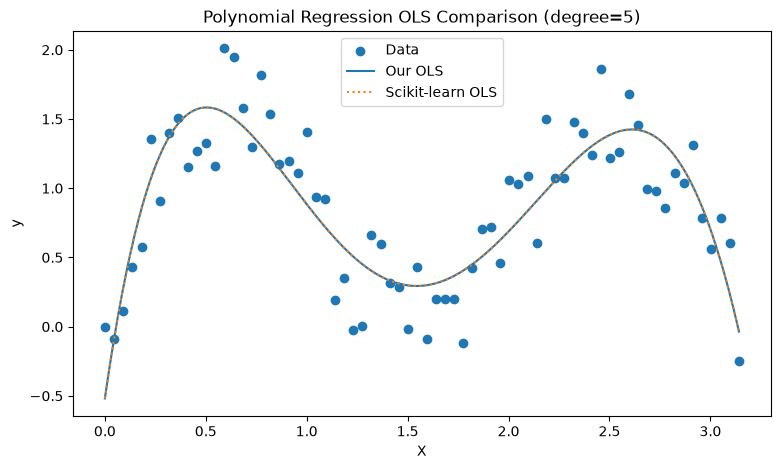

In [7]:
X_plot = np.linspace(X.min(),X.max(),300)

X_plot_poly = polynomial_features(X_plot, degree)
y_plot_ols = predict_multiple_lr(X_plot_poly,theta_ols)


y_plot_sklearn = model.predict(X_plot_poly)

plt.figure(figsize=(9, 5))
plt.scatter(X,y,label="Data")
plt.plot(X_plot,y_plot_ols,label="Our OLS")

plt.plot(X_plot, y_plot_sklearn, ":",label="Scikit-learn OLS")

plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Regression OLS Comparison (degree={degree})")
plt.legend()
plt.show()


## 5. Train-Test Split

### Create the Train-Test Split

The observations are divided into training and testing subsets using an 80/20 split.

The training set is used to estimate the polynomial coefficients, while the test set remains unseen during fitting and is used to evaluate generalization.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 56
Testing samples: 14


## 6. Create Polynomial Features for Train and Test

The same degree-5 polynomial feature representation is created independently for the training and test subsets:

$X_{\text{train,poly}} = [1,X_{\text{train}},X_{\text{train}}^2,X_{\text{train}}^3,X_{\text{train}}^4,X_{\text{train}}^5]$

and

$X_{\text{test,poly}} = [1,X_{\text{test}},X_{\text{test}}^2,X_{\text{test}}^3,X_{\text{test}}^4,X_{\text{test}}^5]$.

Both matrices contain the same six model columns:

$1,\ x,\ x^2,\ x^3,\ x^4,\ x^5$.

The first column is the intercept term, while the remaining columns represent the polynomial powers of the input feature.

In [10]:
X_train_poly = polynomial_features(X_train, degree)

X_test_poly = polynomial_features(X_test, degree)

print("X_train_poly shape:", X_train_poly.shape)
print("X_test_poly shape:", X_test_poly.shape)


X_train_poly shape: (56, 6)
X_test_poly shape: (14, 6)


## 7. Train Using Our Manual OLS

### Train on Training Data and Predict

The coefficients are estimated using the training data only:

$\boxed{
\theta_{\text{train}}
=
(X_{\text{train}}^T X_{\text{train}})^{-1}
X_{\text{train}}^T y_{\text{train}}
}$

The learned coefficients are then used to generate predictions for both the training and test sets:

$\hat{y}_{\text{train}} = X_{\text{train}}\theta_{\text{train}}$

$\hat{y}_{\text{test}} = X_{\text{test}}\theta_{\text{train}}$

The same learned parameter vector $\theta_{\text{train}}$ is used for both predictions. The test data is therefore not used during model training.

In [11]:
# Train only on the training data
theta_train = fit_multiple_lr(X_train_poly, y_train)

# Predictions
y_train_pred = predict_multiple_lr(X_train_poly, theta_train)
y_test_pred = predict_multiple_lr(X_test_poly, theta_train)

## 8. Evaluate Predictions and Residuals

### Evaluate Residuals and $R^2$

Residuals are defined as

$e_i = y_i - \hat{y}_i$.

The notebook calculates the residuals separately for the training and testing datasets.

For either dataset, the coefficient of determination is

$\boxed{
R^2 =
1 -
\frac{\sum_i (y_i-\hat{y}_i)^2}
{\sum_i (y_i-\bar{y})^2}
}$

The notebook reports both $R^2_{\text{train}}$ and $R^2_{\text{test}}$ to evaluate how well the polynomial model fits the training data and generalizes to unseen test data.

In [12]:
# Residuals
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

# R² using our function
y_train_mean = np.mean(y_train)
y_test_mean = np.mean(y_test)

r2_train = r_square(y_train, y_train_pred, y_train_mean)
r2_test = r_square(y_test,y_test_pred, y_test_mean)

print("Train R2:", r2_train)
print("Test R2:", r2_test)


Train R2: 0.7891866294368047
Test R2: 0.35923990302465825


## 9. Final Visualization

### Final Train/Test Visualization

A dense sequence of 300 $X$-values is used to draw a smooth polynomial curve.

The final polynomial feature matrix is

$X_{\text{final,poly}} = [1,X_{\text{final}},X_{\text{final}}^2,\ldots,X_{\text{final}}^d]$

and the fitted curve is

$\hat{y}_{\text{final}} = X_{\text{final,poly}}\theta_{\text{train}}$.

The plot shows the training data, test data, and the polynomial model fitted using only the training observations.

Using a dense sequence of $X$-values produces a smooth visualization of the learned polynomial function.

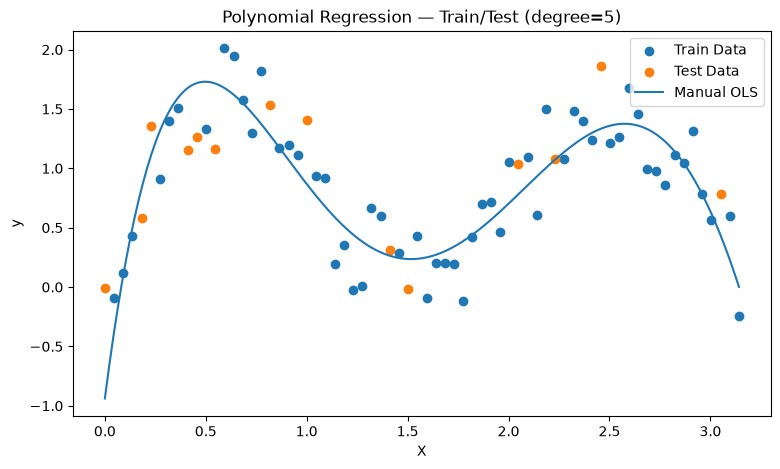

In [13]:
X_final = np.linspace(X.min(), X.max(), 300)

X_final_poly = polynomial_features(X_final, degree)
y_final_pred = predict_multiple_lr(X_final_poly, theta_train)


plt.figure(figsize=(9, 5))
plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, label="Test Data")
plt.plot(X_final, y_final_pred, label="Manual OLS")
plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Regression — Train/Test (degree={degree})")
plt.legend()
plt.show()